In [1]:
import pypsa
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

In [2]:
TITLE_SIZE = 20

In [3]:
n_copperplate = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc')

INFO:pypsa.io:Imported network elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [4]:
# BAU
# n_copperplate = pypsa.Network('/home/groups/iazevedo/kamran/pypsa-usa/workflow/results/CH2/copperplate/texas/networks/elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
# BAU
n_lr_reactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc')
n_lr_proactive = pypsa.Network("/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl33a_ch300a_ec_lvopt_REM-4h_E_mapped_TEP.nc")

n_hr_reactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl300a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc')
n_hr_proactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_c300a_ec_lvopt_REM-4h_E.nc')

INFO:pypsa.io:Imported network elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_cl33a_ch300a_ec_lvopt_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_cl300a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_c300a_ec_lvopt_REM-4h_E.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [5]:
# REM
# n_copperplate_rem = pypsa.Network('/home/groups/iazevedo/kamran/pypsa-usa/workflow/results/CH2/copperplate/texas/networks/elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_lr_reactive_rem = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc')
n_lr_proactive_rem = pypsa.Network("/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl33a_ch300a_ec_lvopt_REM-4h_E_mapped_TEP.nc")

n_hr_reactive_rem = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl300a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc')
n_hr_proactive_rem = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_c300a_ec_lvopt_REM-4h_E.nc')

INFO:pypsa.io:Imported network elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_cl33a_ch300a_ec_lvopt_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_cl300a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_c300a_ec_lvopt_REM-4h_E.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [6]:
n_copperplate.carriers.at['imports','color'] = '#DADADA'
n_lr_reactive.carriers.at['imports','color'] = '#DADADA'
n_hr_reactive.carriers.at['imports','color'] = '#DADADA'
n_lr_proactive.carriers.at['imports','color'] = '#DADADA'
n_hr_proactive.carriers.at['imports','color'] = '#DADADA'
colors = n_hr_reactive.carriers.color

# Extract Statistics

In [7]:
# Extract Line Statistics
# Function to mark lines as interregional or intraregional
def mark_interregional_lines(network):
    network.lines['bus0_zone'] = network.lines['bus0'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['bus1_zone'] = network.lines['bus1'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['interregional'] = network.lines['bus0_zone'] != network.lines['bus1_zone']
    return network
# Mark interregional lines for each network
n_copperplate = mark_interregional_lines(n_copperplate)
n_hr_reactive = mark_interregional_lines(n_hr_reactive)
n_lr_reactive = mark_interregional_lines(n_lr_reactive)
n_lr_proactive = mark_interregional_lines(n_lr_proactive)
n_hr_proactive = mark_interregional_lines(n_hr_proactive)


# Calculate the proportion of interregional vs. intraregional transmission capacity
def calculate_transmission_proportions(network):

    # Calculate new capacity for each line (only positive values)
    new_capacity = (network.lines.s_nom_opt - network.lines.s_nom).clip(lower=0)  / 1e3  # Convert to GW
    new_capacity_length = network.lines.length * new_capacity

    # Calculate total new capacity
    total_new_capacity = new_capacity_length.sum()
    
    # Calculate interregional and intraregional capacity
    interregional_capacity = new_capacity_length[network.lines.interregional].sum()
    intraregional_capacity = new_capacity_length[~network.lines.interregional].sum()
    
    # Calculate new transmission CAPEX
    new_expenditure = new_capacity * network.lines.capital_cost * 1e3 / 1e6 # Convert back to MW then div for B$
    interregional_expenditure = new_expenditure[network.lines.interregional].sum()
    intraregional_expenditure = new_expenditure[~network.lines.interregional].sum()

    return {
        'total_capacity': total_new_capacity,
        'interregional_capacity': interregional_capacity,
        'intraregional_capacity': intraregional_capacity,
        'interregional_capacity_prop': interregional_capacity / total_new_capacity * 100,
        'intraregional_capacity_prop': intraregional_capacity / total_new_capacity * 100,
        'interregional_expenditure': interregional_expenditure,
        'intraregional_expenditure': intraregional_expenditure
    }

# Calculate proportions for each network
copperplate_data = calculate_transmission_proportions(n_copperplate)
lr_reactive_data = calculate_transmission_proportions(n_lr_reactive)
hr_reactive_data = calculate_transmission_proportions(n_hr_reactive)
lr_proactive_data = calculate_transmission_proportions(n_lr_proactive)
hr_proactive_data = calculate_transmission_proportions(n_hr_proactive)


In [8]:
line_statistics_dict = {}
line_statistics_dict['Copperplate Reactive'] = copperplate_data
line_statistics_dict['LowRes Reactive'] = lr_reactive_data
line_statistics_dict['HighRes Reactive'] = hr_reactive_data
line_statistics_dict['LowRes Proactive'] = lr_proactive_data
line_statistics_dict['HighRes Proactive'] = hr_proactive_data

line_statistics_dict

{'Copperplate Reactive': {'total_capacity': 934.8936566723671,
  'interregional_capacity': 112.22665434155665,
  'intraregional_capacity': 822.6670023308105,
  'interregional_capacity_prop': 12.004216045385622,
  'intraregional_capacity_prop': 87.99578395461438,
  'interregional_expenditure': 13.275989404761699,
  'intraregional_expenditure': 97.32689156219087},
 'LowRes Reactive': {'total_capacity': 934.8936566723671,
  'interregional_capacity': 112.22665434155665,
  'intraregional_capacity': 822.6670023308105,
  'interregional_capacity_prop': 12.004216045385622,
  'intraregional_capacity_prop': 87.99578395461438,
  'interregional_expenditure': 13.275989404761699,
  'intraregional_expenditure': 97.32689156219087},
 'HighRes Reactive': {'total_capacity': 18.854509361441995,
  'interregional_capacity': 5.558241549267847,
  'intraregional_capacity': 13.296267812174149,
  'interregional_capacity_prop': 29.479640348714714,
  'intraregional_capacity_prop': 70.52035965128529,
  'interregiona

In [9]:
def extract_statistics(network):
    stats = network.statistics(nice_names=False)

    BESS_stats = stats.loc['StorageUnit'].sum(axis=0)
    idx = pd.MultiIndex.from_tuples([('StorageUnit', 'BESS')])
    bess_df = pd.DataFrame(BESS_stats).T
    bess_df.index = idx

    # Concatenate with original stats dataframe
    stats = pd.concat([stats, bess_df])

    # remove '4hr_battery_storage' from stats
    stats = stats.drop(index=[('StorageUnit', '4hr_battery_storage'), ('StorageUnit', 'battery')])

    return stats

# Create a dictionary to store statistics for each network
statistics_dict = {}

#assign network names to each network
n_copperplate.name = 'Copperplate Reactive'
n_lr_reactive.name = 'LowRes Reactive'
n_hr_reactive.name = 'HighRes Reactive'
n_lr_proactive.name = 'LowRes Proactive'
n_hr_proactive.name = 'HighRes Proactive'

# extract stats for REM networks
# n_copperplate_rem.name = 'Copperplate Reactive REM'
n_lr_reactive_rem.name = 'LowRes Reactive REM'
n_hr_reactive_rem.name = 'HighRes Reactive REM'
n_lr_proactive_rem.name = 'LowRes Proactive REM'
n_hr_proactive_rem.name = 'HighRes Proactive REM'

# Iterate through each network
for network in [n_copperplate, n_lr_reactive, n_hr_reactive, n_lr_proactive, n_hr_proactive, n_lr_reactive_rem, n_hr_reactive_rem, n_lr_proactive_rem, n_hr_proactive_rem]:
    statistics_dict[network.name] = extract_statistics(network)

In [10]:
statistics_dict[network.name]

Optimal Capacity Installed Capacity  \
                                         2040               2040   
Generator   CCGT                  12744.10309          22776.400   
            CCGT-95CCS             2158.23315                NaN   
            EGS                   25481.41742                NaN   
            OCGT                      0.00650          11472.700   
            biomass                 212.30000            212.300   
            coal                      0.00003             55.000   
            geothermal             2719.70000           2719.700   
            hydro                 12976.83700          12976.837   
            hydrogen_ct               0.00090                NaN   
            imports              128000.00000         128000.000   
            nuclear                2323.00428           2323.000   
            offwind_floating          0.00010                NaN   
            oil                       0.00000              0.000   
            onwind                 2769.40271           1198.100   
            solar                 51480.34962          21599.900   
            waste                    59.60000             59.600   
Line        AC                   673535.28294         657558.070   
Link        DC                     5675.00025           5675.000   
Load        AC                        0.00000              0.000   
StorageUnit BESS                  11721.11551          11721.100   

                                    Supply    Withdrawal Energy Balance  \
                                      2040          2040           2040   
Generator   CCGT              4.041219e+07           NaN   4.041219e+07   
            CCGT-95CCS        1.438911e+07           NaN   1.438911e+07   
            EGS               1.799046e+08           NaN   1.799046e+08   
            OCGT              6.195890e+00           NaN   6.195890e+00   
            biomass           1.171647e+06           NaN   1.171647e+06   
            coal              3.377000e-02           NaN   3.377000e-02   
            geothermal        1.227633e+07           NaN   1.227633e+07   
            hydro             2.783327e+07           NaN   2.783327e+07   
            hydrogen_ct       8.933800e-01           NaN   8.933800e-01   
            imports           6.778624e+06           NaN   6.778624e+06   
            nuclear           1.812681e+07           NaN   1.812681e+07   
            offwind_floating  3.930400e-01           NaN   3.930400e-01   
            oil                        NaN           NaN            NaN   
            onwind            5.898560e+06           NaN   5.898560e+06   
            solar             9.638318e+07           NaN   9.638318e+07   
            waste             4.294562e+04           NaN   4.294562e+04   
Line        AC                1.417284e+09  1.417341e+09  -5.722701e+04   
Link        DC                3.301504e+06  3.301504e+06            NaN   
Load        AC                         NaN  4.007187e+08  -4.007187e+08   
StorageUnit BESS              1.381600e+07  1.625743e+07  -2.441422e+06   

                              Transmission Capacity Factor   Curtailment  \
                                      2040            2040          2040   
Generator   CCGT              0.000000e+00        0.361992  6.101046e+07   
            CCGT-95CCS        0.000000e+00        0.761082  4.517008e+06   
            EGS               0.000000e+00        0.805962  5.330419e+06   
            OCGT              0.000000e+00        0.109231  4.589578e+01   
            biomass           0.000000e+00        0.630003  6.661865e+06   
            coal              0.000000e+00             NaN  2.029600e-01   
            geothermal        0.000000e+00        0.515280  3.160129e+06   
            hydro             0.000000e+00        0.244845  4.863038e+04   
            hydrogen_ct       0.000000e+00        0.111111  7.020830e+00   
            imports           0.000000e+00   

In [11]:
capacities = [stats['Optimal Capacity'] for stats in statistics_dict.values()]
# only take Generators and StorageUnit from first level
capacities = [capacity.loc[['Generator', 'StorageUnit']] for capacity in capacities]
# drop the first level of the MultiIndex
capacities = [capacity.droplevel(0) for capacity in capacities]

In [12]:
total_costs_dict = {}
for name, stats in statistics_dict.items():
    capex = stats['Capital Expenditure']
    capex = capex.loc[['Generator','Line', 'StorageUnit']]
    #combine 4hr_battery_storage and battery
    capex = capex.droplevel(0)
    capex.rename(index={'AC': 'Transmission'}, inplace=True)

    # do same for opex
    opex = stats['Operational Expenditure']
    opex = opex.loc[['Generator','Line', 'StorageUnit']] 
    opex = opex.droplevel(0)
    opex.rename(index={'AC': 'Transmission'}, inplace=True)

    # sum the values with same index
    total_costs = capex + opex

    # assign to new dictionary
    total_costs_dict[name] = total_costs
total_costs_dict[name]

,2040
CCGT,1.536735e+09
CCGT-95CCS,8.731486e+08
EGS,8.025131e+09
OCGT,5.446982e+02
biomass,1.361683e+08
coal,5.525750e+00
geothermal,1.182195e+09
hydro,2.448729e+09
hydrogen_ct,2.925563e+02
imports,NaN


In [13]:
# Colors
colors = n_hr_reactive.carriers.color
colors['Transmission'] = colors['AC']
colors['BESS'] = colors['battery']
color_map = colors.to_dict()

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3183/2314454798.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Local vs Inter-regional Development

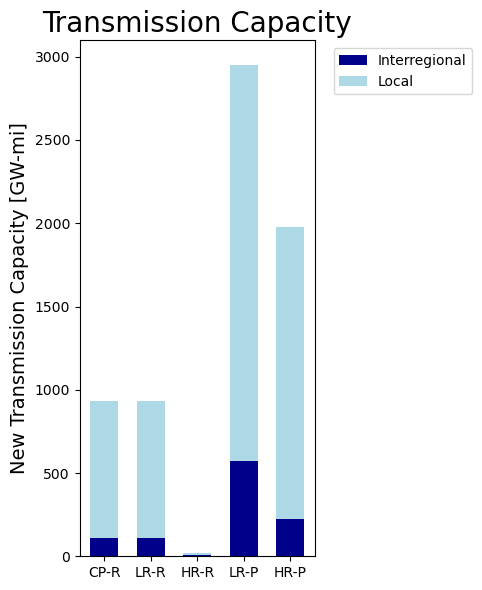

In [14]:

# Set up the data
networks = ['CP-R', 'LR-R', 'HR-R', 'LR-P', 'HR-P']
interregional_caps = [copperplate_data['interregional_capacity'], lr_reactive_data['interregional_capacity'], hr_reactive_data['interregional_capacity'],
lr_proactive_data['interregional_capacity'], hr_proactive_data['interregional_capacity']]

# Capacity
intraregional_caps = [copperplate_data['intraregional_capacity'], lr_reactive_data['intraregional_capacity'], hr_reactive_data['intraregional_capacity'],lr_proactive_data['intraregional_capacity'],hr_proactive_data['intraregional_capacity']]
total_caps = [lr_reactive_data['total_capacity'], hr_reactive_data['total_capacity'],lr_proactive_data['total_capacity'], hr_proactive_data['total_capacity']]

# Capacity proportions
interregional_caps_prop = [copperplate_data['interregional_capacity_prop'], lr_reactive_data['interregional_capacity_prop'], hr_reactive_data['interregional_capacity_prop'],lr_proactive_data['interregional_capacity_prop'], hr_proactive_data['interregional_capacity_prop']]
intraregional_caps_prop = [copperplate_data['intraregional_capacity_prop'], lr_reactive_data['intraregional_capacity_prop'], hr_reactive_data['intraregional_capacity_prop'],lr_proactive_data['intraregional_capacity_prop'], hr_proactive_data['intraregional_capacity_prop']]

# expenditure
interregional_expenditure =  [copperplate_data['interregional_expenditure'], lr_reactive_data['interregional_expenditure'], hr_reactive_data['interregional_expenditure'],lr_proactive_data['interregional_expenditure'], hr_proactive_data['interregional_expenditure']]
intraregional_expenditure = [copperplate_data['intraregional_expenditure'], lr_reactive_data['intraregional_expenditure'], hr_reactive_data['intraregional_expenditure'],lr_proactive_data['intraregional_expenditure'], hr_proactive_data['intraregional_expenditure']]

plot_metric = 'Capacity'
if plot_metric == 'Capex':
    plot_interregional = interregional_expenditure
    plot_intraregional = intraregional_expenditure
    unit = "$M"
    y_label = f"New Transmision Capex [{unit}]"
elif plot_metric == 'Proportions':
    plot_interregional = interregional_caps_prop 
    plot_intraregional = intraregional_caps_prop
    unit = "%"
    y_label = f"New Transmission Capacity Proportions [%]"
elif plot_metric == "Capacity":
    plot_interregional = interregional_caps
    plot_intraregional = intraregional_caps
    unit = "GW-mi"
    y_label = f"New Transmission Capacity [{unit}]"


# Create the plot
fig, ax = plt.subplots(figsize=(5, 6))

# Create the stacked bar plot
x = np.arange(len(networks))
width = 0.6

ax.bar(x, plot_interregional, width, label='Interregional', color='darkblue')
ax.bar(x, plot_intraregional, width, bottom=plot_interregional, label='Local', color='lightblue')

# Add labels and title
ax.set_xlabel('', fontsize=TITLE_SIZE * 0.7)
ax.set_ylabel(y_label, fontsize=TITLE_SIZE * 0.7)
ax.set_title(f'Transmission {plot_metric}', fontsize=TITLE_SIZE)

ax.set_xticks(x)
plt.xticks(rotation=0)  # For the current figure

ax.set_xticklabels(networks)
#move location of legend off the plot to the right
ax.legend(bbox_to_anchor=(1.05, 0.94), loc='center left')

# # Add text labels with absolute values
# for i in range(len(networks)):
#     # Text color based on background darkness
#     interregional_color = intraregional_color = 'white'

#     # Add absolute value labels
#     ax.text(i, plot_interregional[i]/2, f'{plot_interregional[i]:.2f} {unit}', 
#              ha='center', va='center', fontsize=TITLE_SIZE * 0.5, color=interregional_color)
#     ax.text(i, plot_interregional[i] + plot_intraregional[i]/2, f'{plot_intraregional[i]:.2f} {unit}', 
#              ha='center', va='center', fontsize=TITLE_SIZE * 0.5, color=intraregional_color)

# Set y-axis limit to make room for the total capacity text
y_max = max([plot_interregional[i] + plot_intraregional[i] for i in range(len(networks))]) * 1.05
ax.set_ylim(0, y_max)

plt.tight_layout()

# Total System Cost

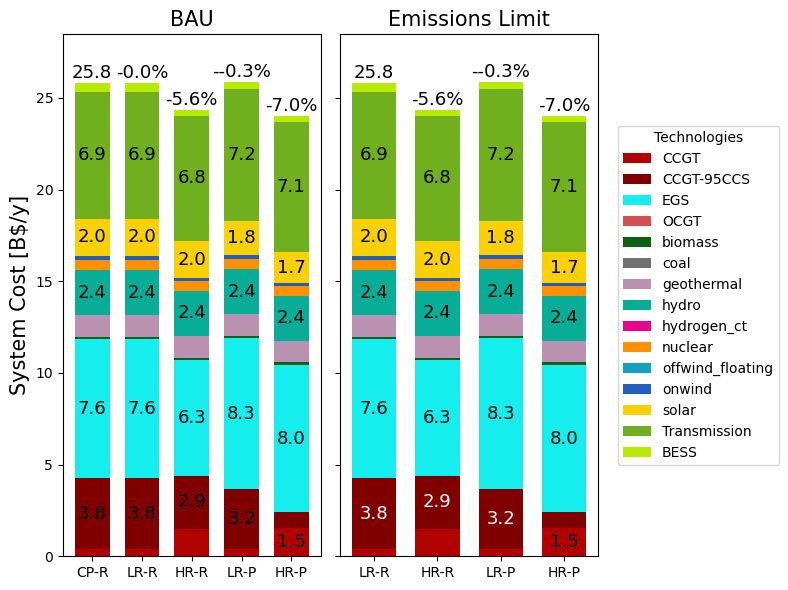

In [15]:
# Create stacked bar plot of total costs
total_costs_dict

LABEL_FONT_SIZE = 13
TITLE_FONT_SIZE = 15

# Extract data for plotting
networks = list(total_costs_dict.keys())
technologies = list(total_costs_dict[networks[0]].index)

# define order of networks
networks = ['Copperplate Reactive', 'LowRes Reactive', 'HighRes Reactive', 'LowRes Proactive', 'HighRes Proactive']
networks_rem = ['LowRes Reactive REM', 'HighRes Reactive REM', 'LowRes Proactive REM', 'HighRes Proactive REM']

# Define alternate names for x-axis labels
network_labels = {
    'Copperplate Reactive': 'CP-R',
    'LowRes Reactive': 'LR-R',
    'HighRes Reactive': 'HR-R', 
    'LowRes Proactive': 'LR-P',
    'HighRes Proactive': 'HR-P'
}

# Add labels to plot
network_rem_labels = {
    'Copperplate Reactive': 'a',
    'LowRes Reactive REM': 'b',
    'HighRes Reactive REM': 'c',
    'LowRes Proactive REM': 'd', 
    'HighRes Proactive REM': 'e'
}


# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,6))

# Add titles to subplots
ax1.set_title('BAU', fontsize=TITLE_FONT_SIZE)
ax2.set_title('Emissions Limit', fontsize=TITLE_FONT_SIZE)

# First subplot - original networks
x1 = np.arange(len(networks))
width = 0.7
bottom1 = np.zeros(len(networks))

# Second subplot - REM networks  
x2 = np.arange(len(networks_rem))
bottom2 = np.zeros(len(networks_rem))

# Create stacked bars for each subplot
for tech in technologies:
    # Values for original networks
    values1 = [total_costs_dict[network].loc[tech][2040] /1e9 for network in networks]
    if not np.isnan(values1).all():
        ax1.bar(x1, values1, width, bottom=bottom1, label=tech, color=color_map[tech])
        bottom1 += np.nan_to_num(values1)
        
    # Values for REM networks    
    values2 = [total_costs_dict[network].loc[tech][2040] /1e9 for network in networks_rem]
    if not np.isnan(values2).all():
        ax2.bar(x2, values2, width, bottom=bottom2, label=tech, color=color_map[tech])
        bottom2 += np.nan_to_num(values2)


# Add value labels for first subplot
for i, network in enumerate(networks):
    bottom = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value) and abs(value) >= 1.5:
            height = value
            ax1.text(i, bottom + height/2, f'{value:.1f}', 
                    ha='center', va='center',
                    color='black', 
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value
            
# Add value labels for second subplot            
for i, network in enumerate(networks_rem):
    bottom = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value) and abs(value) >= 1.5:
            height = value
            if tech == 'CCGT-95CCS':
                TEXT_COLOR = 'white'
            else:
                TEXT_COLOR = 'black'
            ax2.text(i, bottom + height/2, f'{value:.1f}',
                    ha='center', va='center',
                    color=TEXT_COLOR,
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value

# Calculate totals for first subplot
total_heights1 = []
for network in networks:
    total = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value):
            total += value
    total_heights1.append(total)

# Calculate totals for second subplot    
total_heights2 = []
for network in networks_rem:
    total = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value):
            total += value
    total_heights2.append(total)

# Add total and reduction labels for first subplot
ax1.text(0, total_heights1[0] + 0.05, f'{total_heights1[0]:.1f}',
         ha='center', va='bottom',
         color='black',
         fontsize=LABEL_FONT_SIZE)

for i in range(1, len(networks)):
    pct_reduction = ((total_heights1[0] - total_heights1[i]) / total_heights1[0]) * 100
    ax1.text(i, total_heights1[i] + 0.05, f'-{pct_reduction:.1f}%',
             ha='center', va='bottom', 
             color='black',
             fontsize=LABEL_FONT_SIZE)

# Add total and reduction labels for second subplot             
ax2.text(0, total_heights2[0] + 0.05, f'{total_heights2[0]:.1f}',
         ha='center', va='bottom',
         color='black', 
         fontsize=LABEL_FONT_SIZE)

for i in range(1, len(networks_rem)):
    pct_reduction = ((total_heights2[0] - total_heights2[i]) / total_heights2[0]) * 100
    ax2.text(i, total_heights2[i] + 0.05, f'-{pct_reduction:.1f}%',
             ha='center', va='bottom',
             color='black',
             fontsize=LABEL_FONT_SIZE)


# Set x-axis labels
ax1.set_xticks(x1)
ax1.set_xticklabels([network_labels[n] for n in networks])
ax2.set_xticks(x2) 
ax2.set_xticklabels([network_labels[n.replace(' REM','')] for n in networks_rem])


# Add legend to right of second subplot
ax2.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', title='Technologies')

# Set same y limits for both plots
max_height = max(max(total_heights1), max(total_heights2))
ax1.set_ylim(0, max_height * 1.1)
ax2.set_ylim(0, max_height * 1.1)

# set one y axis label
ax1.set_ylabel('System Cost [B$/y]', fontsize=TITLE_FONT_SIZE)
#remove y axis tick labels for second subplot
ax2.set_yticklabels([])
plt.tight_layout()

In [16]:
new_capacities_dict = {}
for name, stats in statistics_dict.items():
    supply = stats['Supply']
    supply = supply.loc[['Generator', 'StorageUnit']]
    total_supply = supply.sum()
    #combine 4hr_battery_storage and battery
    supply = supply.droplevel(0)
    supply.rename(index={'AC': 'Transmission'}, inplace=True)
    # assign to new dictionary
    new_capacities_dict[name] = (supply/total_supply).round(4).fillna(0).mul(100)
new_capacities_dict[name]



,2040
CCGT,9.69
CCGT-95CCS,3.45
EGS,43.14
OCGT,0.00
biomass,0.28
coal,0.00
geothermal,2.94
hydro,6.67
hydrogen_ct,0.00
imports,1.63


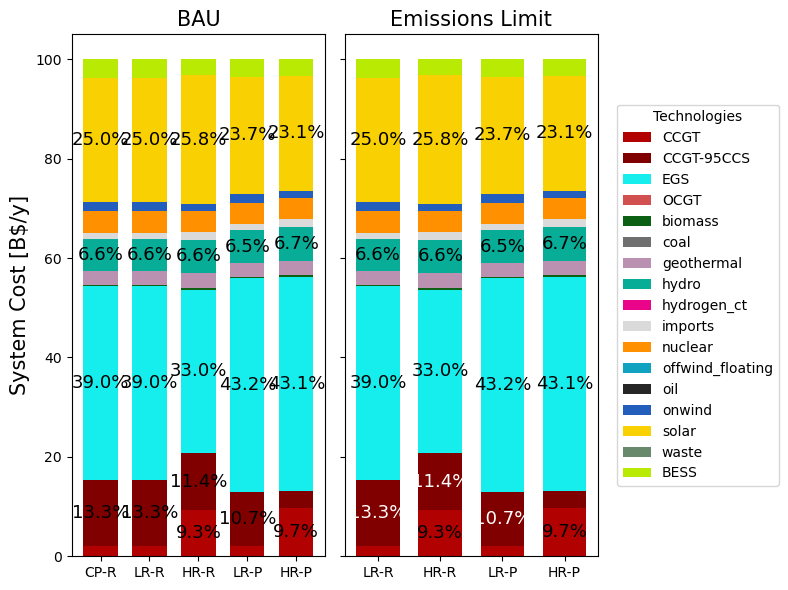

In [17]:
LABEL_FONT_SIZE = 13
TITLE_FONT_SIZE = 15

# Extract data for plotting
networks = list(new_capacities_dict.keys())
technologies = list(new_capacities_dict[networks[0]].index)

# define order of networks
networks = ['Copperplate Reactive', 'LowRes Reactive', 'HighRes Reactive', 'LowRes Proactive', 'HighRes Proactive']
networks_rem = ['LowRes Reactive REM', 'HighRes Reactive REM', 'LowRes Proactive REM', 'HighRes Proactive REM']

# Define alternate names for x-axis labels
network_labels = {
    'Copperplate Reactive': 'CP-R',
    'LowRes Reactive': 'LR-R',
    'HighRes Reactive': 'HR-R', 
    'LowRes Proactive': 'LR-P',
    'HighRes Proactive': 'HR-P'
}

# Add labels to plot
network_rem_labels = {
    'Copperplate Reactive': 'a',
    'LowRes Reactive REM': 'b',
    'HighRes Reactive REM': 'c',
    'LowRes Proactive REM': 'd', 
    'HighRes Proactive REM': 'e'
}


# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,6))

# Add titles to subplots
ax1.set_title('BAU', fontsize=TITLE_FONT_SIZE)
ax2.set_title('Emissions Limit', fontsize=TITLE_FONT_SIZE)

# First subplot - original networks
x1 = np.arange(len(networks))
width = 0.7
bottom1 = np.zeros(len(networks))

# Second subplot - REM networks  
x2 = np.arange(len(networks_rem))
bottom2 = np.zeros(len(networks_rem))

# Create stacked bars for each subplot
for tech in technologies:
    # Values for original networks
    values1 = [new_capacities_dict[network].loc[tech][2040] for network in networks]
    if not np.isnan(values1).all():
        ax1.bar(x1, values1, width, bottom=bottom1, label=tech, color=color_map[tech])
        bottom1 += np.nan_to_num(values1)
        
    # Values for REM networks    
    values2 = [new_capacities_dict[network].loc[tech][2040] for network in networks_rem]
    if not np.isnan(values2).all():
        ax2.bar(x2, values2, width, bottom=bottom2, label=tech, color=color_map[tech])
        bottom2 += np.nan_to_num(values2)

# Add value labels for first subplot
for i, network in enumerate(networks):
    bottom = 0
    for tech in technologies:
        value = new_capacities_dict[network].loc[tech][2040] 
        if not np.isnan(value) and abs(value) >= 5:
            height = value
            ax1.text(i, bottom + height/2, f'{value:.1f}%', 
                    ha='center', va='center',
                    color='black', 
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value
            
# Add value labels for second subplot            
for i, network in enumerate(networks_rem):
    bottom = 0
    for tech in technologies:
        value = new_capacities_dict[network].loc[tech][2040]
        if not np.isnan(value) and abs(value) >= 5:
            height = value
            if tech == 'CCGT-95CCS':
                TEXT_COLOR = 'white'
            else:
                TEXT_COLOR = 'black'
            ax2.text(i, bottom + height/2, f'{value:.1f}%',
                    ha='center', va='center',
                    color=TEXT_COLOR,
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value


# Set x-axis labels
ax1.set_xticks(x1)
ax1.set_xticklabels([network_labels[n] for n in networks])
ax2.set_xticks(x2) 
ax2.set_xticklabels([network_labels[n.replace(' REM','')] for n in networks_rem])

# Add legend to right of second subplot
ax2.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', title='Technologies')

# Set same y limits for both plots
max_height =100
ax1.set_ylim(0, max_height * 1.05)
ax2.set_ylim(0, max_height * 1.05)

# set one y axis label
ax1.set_ylabel('System Cost [B$/y]', fontsize=TITLE_FONT_SIZE)
#remove y axis tick labels for second subplot
ax2.set_yticklabels([])
plt.tight_layout()